In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_wc_2026 = pd.read_csv("./t20_world_cup_2026_data.csv")
df_wc_2026.head(5)

,Player Name,Player_Type,Matches_Played,Runs,Average,Strike_Rate,Wickets,Bowling_average,Economy,Bowling_Strike_Rate,Catches
0,Sahibzada Farhan (PAK),Batter,7,383.0,76.6,160.25,NaN,NaN,NaN,NaN,NaN
1,TL Seifert (NZ),Keeper,9,326.0,46.57,166.32,NaN,NaN,NaN,NaN,7.0
2,SV Samson (IND),Keeper,5,321.0,80.25,199.37,NaN,NaN,NaN,NaN,3.0
3,Ishan Kishan (IND),Keeper,9,317.0,35.22,193.29,NaN,NaN,NaN,NaN,9.0
4,FH Allen (NZ),Batter,9,298.0,49.66,200.00,NaN,NaN,NaN,NaN,2.0


In [3]:
df_wc_2026['Country'] = df_wc_2026["Player Name"].str.extract(r'\((.*?)\)')
df_wc_2026["Player Name"] = df_wc_2026["Player Name"].str.replace(r'\s*\(.*?\)', '', regex = True)
df_wc_2026.head(5)

,Player Name,Player_Type,Matches_Played,Runs,Average,Strike_Rate,Wickets,Bowling_average,Economy,Bowling_Strike_Rate,Catches,Country
0,Sahibzada Farhan,Batter,7,383.0,76.6,160.25,NaN,NaN,NaN,NaN,NaN,PAK
1,TL Seifert,Keeper,9,326.0,46.57,166.32,NaN,NaN,NaN,NaN,7.0,NZ
2,SV Samson,Keeper,5,321.0,80.25,199.37,NaN,NaN,NaN,NaN,3.0,IND
3,Ishan Kishan,Keeper,9,317.0,35.22,193.29,NaN,NaN,NaN,NaN,9.0,IND
4,FH Allen,Batter,9,298.0,49.66,200.00,NaN,NaN,NaN,NaN,2.0,NZ


In [4]:
df_wc_2026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Player Name          209 non-null    object 
 1   Player_Type          209 non-null    object 
 2   Matches_Played       209 non-null    int64  
 3   Runs                 150 non-null    float64
 4   Average              150 non-null    object 
 5   Strike_Rate          150 non-null    float64
 6   Wickets              100 non-null    float64
 7   Bowling_average      100 non-null    float64
 8   Economy              100 non-null    float64
 9   Bowling_Strike_Rate  100 non-null    float64
 10  Catches              17 non-null     float64
 11  Country              209 non-null    object 
dtypes: float64(7), int64(1), object(4)
memory usage: 19.7+ KB


In [21]:
df_wc_2026.fillna(0, inplace = True)

In [24]:
df_wc_2026.isna().any()

Player Name            False
Player_Type            False
Matches_Played         False
Runs                   False
Average                False
Strike_Rate            False
Wickets                False
Bowling_average        False
Economy                False
Bowling_Strike_Rate    False
Catches                False
Country                False
dtype: bool

In [22]:
df_wc_2026.head(2)

,Player Name,Player_Type,Matches_Played,Runs,Average,Strike_Rate,Wickets,Bowling_average,Economy,Bowling_Strike_Rate,Catches,Country
0,Sahibzada Farhan,Batter,7,383.0,76.60,160.25,0.0,0.0,0.0,0.0,0.0,PAK
1,TL Seifert,Keeper,9,326.0,46.57,166.32,0.0,0.0,0.0,0.0,7.0,NZ


In [7]:
df_wc_2026['Average'] = pd.to_numeric(df_wc_2026['Average'], errors = 'coerce')

In [26]:
batsmen = df_wc_2026.loc[df_wc_2026["Player_Type"] == "Batter",
                        ['Player Name','Country','Matches_Played', 'Runs', 'Strike_Rate', 'Average']]
top_batsmen = batsmen.loc[(batsmen["Average"] >= 35) & (batsmen["Runs"] >= 180) & (batsmen["Strike_Rate"] >= 150)]
top_batsmen_runs = top_batsmen.sort_values("Runs", ascending = False)
top_batsmen_runs.head()

,Player Name,Country,Matches_Played,Runs,Strike_Rate,Average
0,Sahibzada Farhan,PAK,7,383.0,160.25,76.60
4,FH Allen,NZ,9,298.0,200.00,49.66
6,AK Markram,SA,8,286.0,165.31,47.66
7,JG Bethell,ENG,8,280.0,152.17,35.00
8,SO Hetmyer,WI,7,248.0,186.46,41.33


In [9]:
bowler = df_wc_2026.loc[df_wc_2026["Player_Type"] == "Bowler",
                        ['Player Name','Country','Matches_Played','Wickets', 'Economy', 'Bowling_average', 'Bowling_Strike_Rate']]
top_bowler = bowler.loc[(bowler["Wickets"] >= 10) & (bowler["Economy"] <= 7.5)]
top_bowler_wickets = top_bowler.sort_values("Wickets", ascending = False)
top_bowler_wickets.head()

,Player Name,Country,Matches_Played,Wickets,Economy,Bowling_average,Bowling_Strike_Rate
150,JJ Bumrah,IND,8,14.0,6.21,12.42,12.00
152,SC van Schalkwyk,USA,4,13.0,6.80,7.76,6.84
155,L Ngidi,SA,7,12.0,7.19,15.58,13.00
156,M Theekshana,SL,7,11.0,7.41,18.54,15.00
159,Usman Tariq,PAK,6,10.0,7.23,14.10,11.70


In [10]:
keeper = df_wc_2026.loc[df_wc_2026["Player_Type"] == "Keeper",
                        ["Player Name","Country", "Matches_Played", "Runs", "Strike_Rate", "Average", "Catches"]]
top_keeper = keeper.loc[(keeper["Average"] >= 30) & (keeper["Strike_Rate"] >= 160)]
top_keeper_k = top_keeper.sort_values("Runs", ascending = False)
top_keeper_k.head()

,Player Name,Country,Matches_Played,Runs,Strike_Rate,Average,Catches
1,TL Seifert,NZ,9,326.0,166.32,46.57,7.0
2,SV Samson,IND,5,321.0,199.37,80.25,3.0
3,Ishan Kishan,IND,9,317.0,193.29,35.22,9.0
12,RD Rickelton,SA,8,228.0,170.14,32.57,0.0


In [11]:
all_rounders = df_wc_2026.loc[df_wc_2026["Player_Type"] == "Allrounder",
                            ["Player Name","Country","Matches_Played", "Runs", "Strike_Rate","Wickets","Economy","Bowling_average","Bowling_Strike_Rate", "Catches"]]
top_all_rounders = all_rounders.loc[(all_rounders["Runs"] >= 125) & (all_rounders["Wickets"] >= 6)]
top_all_rounders.head()

,Player Name,Country,Matches_Played,Runs,Strike_Rate,Wickets,Economy,Bowling_average,Bowling_Strike_Rate,Catches
13,WG Jacks,ENG,8,226.0,176.56,9.0,9.75,21.66,13.33,0.0
14,HH Pandya,IND,9,217.0,160.74,9.0,8.81,32.33,22.00,0.0
28,SM Curran,ENG,8,167.0,120.14,6.0,9.46,34.16,21.66,0.0
37,JO Holder,WI,7,141.0,174.07,10.0,8.86,20.40,13.80,0.0
47,R Ravindra,NZ,9,129.0,134.37,12.0,7.84,12.41,9.50,2.0


In [66]:
# This is to get top run getters irrespective of role(i.e batsman or keeper or all-rounder)
top_run_getters = df_wc_2026.sort_values(by = "Runs", ascending = False).head(5)
top_run_getters

,Player Name,Player_Type,Matches_Played,Runs,Average,Strike_Rate,Wickets,Bowling_average,Economy,Bowling_Strike_Rate,Catches,Country
0,Sahibzada Farhan,Batter,7,383.0,76.60,160.25,0.0,0.0,0.0,0.0,0.0,PAK
1,TL Seifert,Keeper,9,326.0,46.57,166.32,0.0,0.0,0.0,0.0,7.0,NZ
2,SV Samson,Keeper,5,321.0,80.25,199.37,0.0,0.0,0.0,0.0,3.0,IND
3,Ishan Kishan,Keeper,9,317.0,35.22,193.29,0.0,0.0,0.0,0.0,9.0,IND
4,FH Allen,Batter,9,298.0,49.66,200.00,0.0,0.0,0.0,0.0,2.0,NZ


In [67]:
# This is to get top wicket takers irrespective of role(i.e. bowler or all-rounder)
top_wicket_takers = df_wc_2026.sort_values(by = "Wickets", ascending = False).head(5)
top_wicket_takers

,Player Name,Player_Type,Matches_Played,Runs,Average,Strike_Rate,Wickets,Bowling_average,Economy,Bowling_Strike_Rate,Catches,Country
150,JJ Bumrah,Bowler,8,0.0,0.0,0.0,14.0,12.42,6.21,12.00,0.0,IND
151,CV Varun,Bowler,9,0.0,0.0,0.0,14.0,20.50,9.25,13.28,0.0,IND
152,SC van Schalkwyk,Bowler,4,0.0,0.0,0.0,13.0,7.76,6.80,6.84,0.0,USA
154,AU Rashid,Bowler,8,0.0,0.0,0.0,13.0,19.23,8.15,14.15,0.0,ENG
153,B Muzarabani,Bowler,6,0.0,0.0,0.0,13.0,14.46,7.88,11.00,0.0,ZIM


In [69]:
most_economical_bowler = df_wc_2026[df_wc_2026["Player_Type"].isin(["Bowler", "Allrounder"]) & (df_wc_2026["Matches_Played"] >= 5)
                                    ].sort_values(by = "Economy", ascending = True).head(5)
most_economical_bowler

,Player Name,Player_Type,Matches_Played,Runs,Average,Strike_Rate,Wickets,Bowling_average,Economy,Bowling_Strike_Rate,Catches,Country
150,JJ Bumrah,Bowler,8,0.0,0.0,0.00,14.0,12.42,6.21,12.00,0.0,IND
136,MW Forde,Bowler,6,29.0,29.0,145.00,6.0,20.50,6.25,19.66,0.0,WI
48,MJ Santner,Allrounder,8,120.0,40.0,142.85,2.0,92.50,6.60,84.00,0.0,NZ
155,L Ngidi,Bowler,7,0.0,0.0,0.00,12.0,15.58,7.19,13.00,0.0,SA
90,DN Wellalage,Allrounder,7,72.0,24.0,118.03,8.0,24.37,7.22,20.25,0.0,SL


In [12]:
best_batsmen = top_batsmen_runs.head(3)
best_keepers = top_keeper_k.head(2)
best_all_rounders = top_all_rounders.head(2)
best_bowlers = top_bowler_wickets.head(4)

best_batsmen
best_keepers
best_all_rounders
best_bowlers

,Player Name,Country,Matches_Played,Wickets,Economy,Bowling_average,Bowling_Strike_Rate
150,JJ Bumrah,IND,8,14.0,6.21,12.42,12.00
152,SC van Schalkwyk,USA,4,13.0,6.80,7.76,6.84
155,L Ngidi,SA,7,12.0,7.19,15.58,13.00
156,M Theekshana,SL,7,11.0,7.41,18.54,15.00


In [35]:
best_batsmen["Role"] = "Batsman"
best_bowlers["Role"] = "Bowler"
best_keepers["Role"] = "WicketKeeper"
best_all_rounders["Role"] = "AllRounder"

tournament_xi = pd.concat([
    best_batsmen,
    best_bowlers,
    best_keepers,
    best_all_rounders
], ignore_index = True)

role_order = ["Batsman","WicketKeeper", "AllRounder", "Bowler"]
tournament_xi["Role"] = pd.Categorical(
    tournament_xi["Role"],
    categories= role_order,
    ordered = True
    )

tournament_xi = tournament_xi.sort_values("Role")
tournament_xi[["Player Name", "Role"]]

C:\Users\aryam\AppData\Local\Temp\ipykernel_24884\199090796.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_bowlers["Role"] = "Bowler"
C:\Users\aryam\AppData\Local\Temp\ipykernel_24884\199090796.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_keepers["Role"] = "WicketKeeper"
C:\Users\aryam\AppData\Local\Temp\ipykernel_24884\199090796.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

,Player Name,Role
0,Sahibzada Farhan,Batsman
1,FH Allen,Batsman
2,AK Markram,Batsman
7,TL Seifert,WicketKeeper
8,SV Samson,WicketKeeper
9,WG Jacks,AllRounder
10,HH Pandya,AllRounder
3,JJ Bumrah,Bowler
4,SC van Schalkwyk,Bowler
5,L Ngidi,Bowler


In [33]:
reserve_batsman = top_batsmen_runs.iloc[3:4][["Player Name", "Country"]]
reserve_bowler = top_bowler_wickets.iloc[4:5][["Player Name", "Country"]]
reserve_keeper = top_keeper_k.iloc[2:3][["Player Name", "Country"]]
reserve_all_rounder = top_all_rounders.iloc[2:3][["Player Name", "Country"]]

reserve_batsman["Role"] = "Batsman"
reserve_bowler["Role"] = "Bowler"
reserve_keeper["Role"] = "WicketKeeper"
reserve_all_rounder["Role"] = "AllRounder"

reserve_four = pd.concat([
    reserve_batsman,
    reserve_bowler,
    reserve_keeper,
    reserve_all_rounder
], ignore_index = True)

role_order = ["Batsman", "WicketKeeper", "AllRounder", "Bowler"]
reserve_four["Role"] = pd.Categorical(reserve_four["Role"], categories=role_order, ordered=True)

reserve_four = reserve_four.sort_values("Role")
reserve_four = reserve_four[["Player Name", "Role"]]

reserve_four

,Player Name,Role
0,JG Bethell,Batsman
2,Ishan Kishan,WicketKeeper
3,SM Curran,AllRounder
1,Usman Tariq,Bowler


In [39]:
role_count = df_wc_2026["Player_Type"].value_counts()
role_count

Batter        98
Bowler        64
Allrounder    35
Keeper        12
Name: Player_Type, dtype: int64

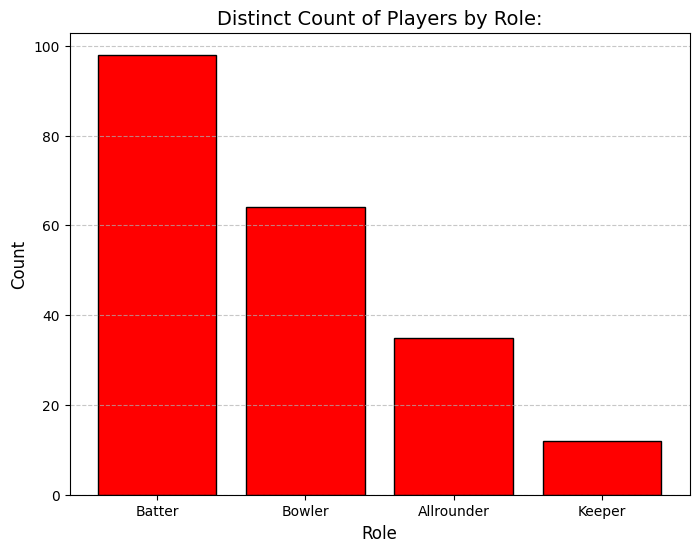

In [42]:
plt.figure(figsize = (8,6))
plt.bar(role_count.index, role_count.values, color= "red", edgecolor = "black")
plt.title("Distinct Count of Players by Role:", fontsize = 14)
plt.xlabel("Role", fontsize = 12)
plt.ylabel("Count", fontsize = 12)
plt.grid(axis = "y", linestyle = "--", alpha = 0.7)
plt.show()

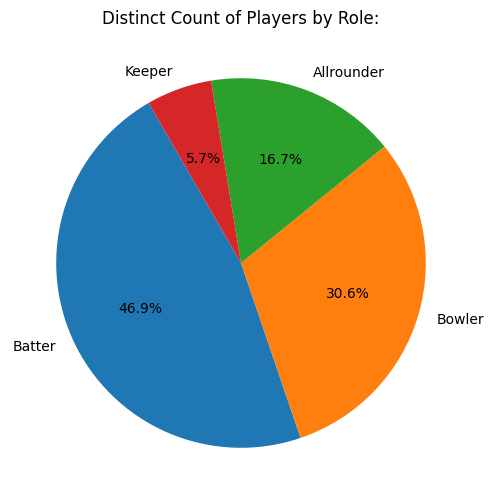

In [44]:
plt.figure(figsize= (6,6))
plt.pie(role_count.values,
        labels = role_count.index,
        autopct="%1.1f%%",
        startangle = 120
        )
plt.title("Distinct Count of Players by Role:")
plt.show()

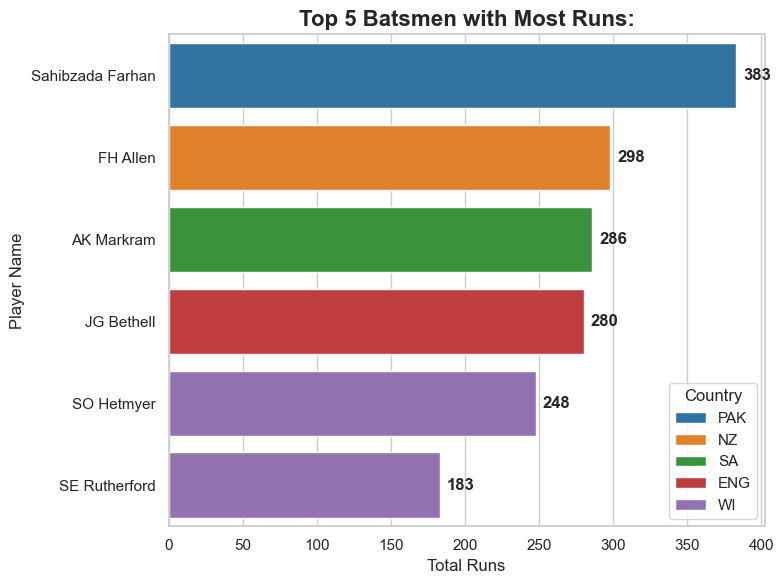

In [60]:
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (8, 6))

barplot = sns.barplot(
    data = top_batsmen_runs,
    x = "Runs",
    y = "Player Name",
    hue = "Country",
    dodge = False, 
    palette = "tab10"
)

# Data labels for each bar
for container in barplot.containers: 
    barplot.bar_label(container, padding = 5, fontweight = "bold")

plt.title("Top 5 Batsmen with Most Runs:", fontsize= 16, fontweight = "bold")
plt.xlabel("Total Runs", fontsize = 12)
plt.ylabel("Player Name", fontsize = 12)
plt.legend(title = "Country", loc= "lower right")
plt.tight_layout()
plt.show()

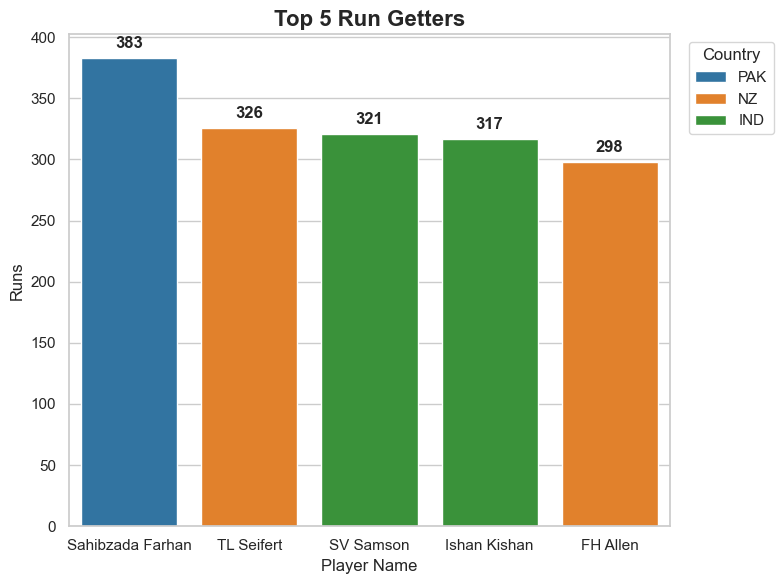

In [87]:
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (8, 6))

barplot = sns.barplot(
    data = top_run_getters,
    x = "Player Name",
    y = "Runs",
    hue = "Country",
    dodge = False, 
    palette = "tab10"
)

# Data labels for each bar
for container in barplot.containers: 
    barplot.bar_label(container, padding = 5, fontweight = "bold")

plt.title("Top 5 Run Getters", fontsize= 16, fontweight = "bold")
plt.xlabel("Player Name", fontsize = 12)
plt.ylabel("Runs", fontsize = 12)
plt.legend(title = "Country", bbox_to_anchor= (1.02, 1), loc= "upper left")
plt.tight_layout()
plt.show()

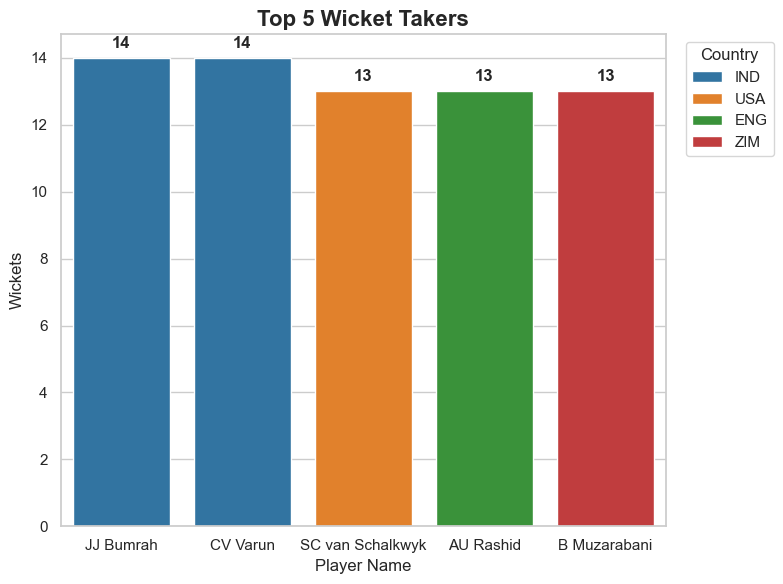

In [84]:
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (8, 6))

barplot = sns.barplot(
    data = top_wicket_takers,
    x = "Player Name",
    y = "Wickets",
    hue = "Country",
    dodge = False, 
    palette = "tab10"
)

# Data labels for each bar
for container in barplot.containers: 
    barplot.bar_label(container, padding = 5, fontweight = "bold")

plt.title("Top 5 Wicket Takers", fontsize= 16, fontweight = "bold")
plt.xlabel("Player Name", fontsize = 12)
plt.ylabel("Wickets", fontsize = 12)
plt.legend(title = "Country", bbox_to_anchor= (1.02, 1), loc= "upper left")
plt.tight_layout()
plt.show()

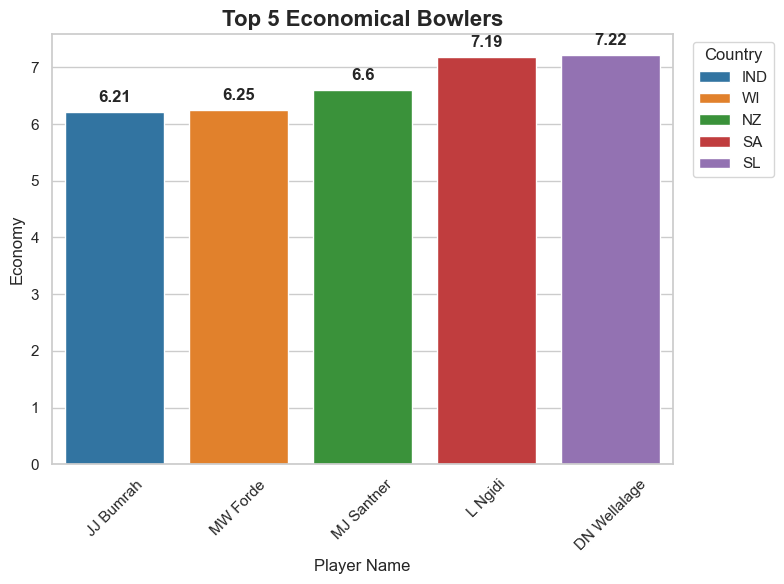

In [92]:
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (8, 6))

barplot = sns.barplot(
    data = most_economical_bowler,
    x = "Player Name",
    y = "Economy",
    hue = "Country",
    dodge = False, 
    palette = "tab10"
)

# Data labels for each bar
for container in barplot.containers: 
    barplot.bar_label(container, padding = 5, fontweight = "bold")

plt.title("Top 5 Economical Bowlers", fontsize= 16, fontweight = "bold")
plt.xlabel("Player Name", fontsize = 12)
plt.ylabel("Economy", fontsize = 12)
plt.legend(title = "Country", bbox_to_anchor= (1.02, 1), loc= "upper left")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

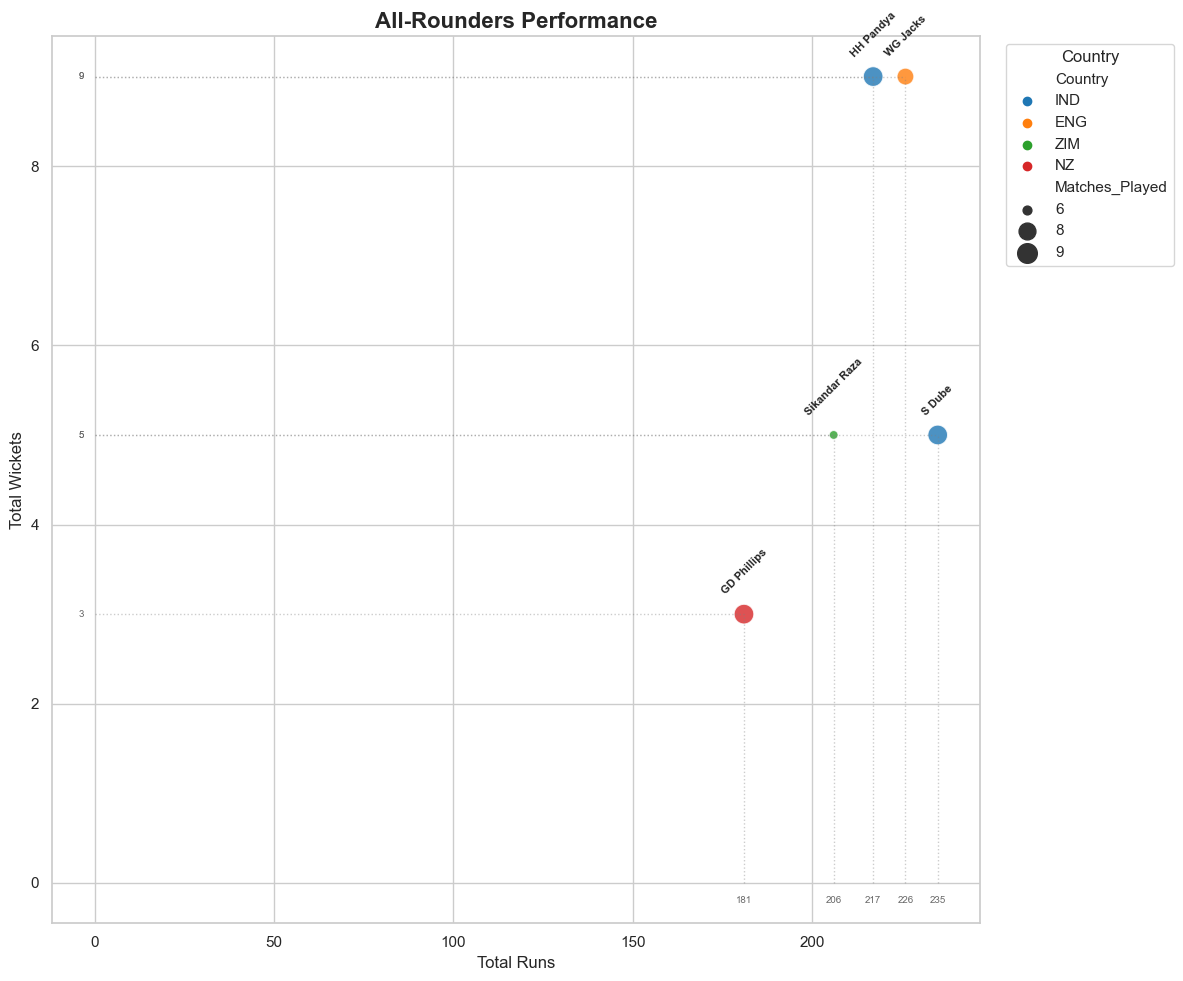

In [122]:
all_rounders = df_wc_2026[df_wc_2026["Player_Type"] == "Allrounder"].head(5)

sns.set_theme(style = "whitegrid")
plt.figure(figsize = (12, 10))

scatterplot = sns.scatterplot(
    data = all_rounders, 
    x = "Runs",
    y= "Wickets",
    hue = "Country",
    size = "Matches_Played",
    sizes = (40, 200,),
    palette = "tab10",
    alpha = 0.8
)

for i, row in all_rounders.iterrows():
    runs = int(row["Runs"])
    wickets = int(row["Wickets"])
    
    plt.vlines(
        x = runs,
        ymin = 0,
        ymax = wickets,
        colors= "gray",
        linestyles = "dotted",
        linewidth = 1,
        alpha = 0.4, 
        zorder = 1
    )
    
    plt.hlines(
            y = wickets,
            xmin = 0,
            xmax = runs,
            colors= "gray",
            linestyles = "dotted",
            linewidth = 1,
            alpha = 0.4, 
            zorder = 1
    )
    
    plt.text(
        x = runs,
        y = wickets + 0.20, 
        s = row["Player Name"],
        fontsize = 8,
        fontweight = "bold",
        ha = "center",
        va = "bottom",
        rotation = 45
    )
    
    plt.text(
        x = runs, 
        y = -0.15,
        s = str(runs),
        fontsize = 7,
        color = "dimgray",
        ha = "center", 
        va = "top",
    )
    
    plt.text(
        x = -3,
        y = wickets, 
        s = str(wickets),
        fontsize = 7,
        color = "dimgray",
        ha = "right",
        va = "center",
    )
  
    

plt.title("All-Rounders Performance", fontsize= 16, fontweight = "bold")
plt.xlabel("Total Runs", fontsize = 12)
plt.ylabel("Total Wickets", fontsize = 12)
plt.legend(title = "Country", bbox_to_anchor= (1.02, 1), loc= "upper left")
plt.tight_layout()
plt.show()
